# Evo-Phage Embedding + Similarity Analysis

- Input: `data/evo-phage-seq.csv`
- Embedding cache only: `data/embeddings/evo-phage/`
- Models: `DNABERT-2`, `NT-v2-500m`, `NT-v3-650m-post`
- Output files are not saved except embedding caches.


In [1]:
import gc
import sys
from pathlib import Path

import numpy as np
import pandas as pd


def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'data' / 'evo-phage-seq.csv').exists() and (p / '01_generate-seq-and-emb').exists():
            return p
    raise FileNotFoundError('Repository root not found from current working directory.')


REPO_ROOT = find_repo_root()
WORK_DIR = REPO_ROOT / '01_generate-seq-and-emb'
DATA_PATH = REPO_ROOT / 'data' / 'evo-phage-seq.csv'
EMB_CACHE_DIR = REPO_ROOT / 'data' / 'embeddings' / 'evo-phage'
EMB_CACHE_DIR.mkdir(parents=True, exist_ok=True)

SRC_DIR = WORK_DIR / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from idr.utils import get_device, load_model

MODEL_CONFIGS = {
    'DNABERT-2': 'zhihan1996/DNABERT-2-117M',
    'NT-v2-500m': 'InstaDeepAI/nucleotide-transformer-v2-500m-multi-species',
    # 'NT-v3-650m-post': 'InstaDeepAI/NTv3_650M_post',
}

CHUNK_SIZE = 1024
CHUNK_OVERLAP = 128

print('Repo root:', REPO_ROOT)
print('Data path:', DATA_PATH)
print('Embedding cache dir:', EMB_CACHE_DIR)


Repo root: /Users/leeminjae/Library/Mobile Documents/com~apple~CloudDocs/Desktop/01_Projects/iterative-dna-reconstruction
Data path: /Users/leeminjae/Library/Mobile Documents/com~apple~CloudDocs/Desktop/01_Projects/iterative-dna-reconstruction/data/evo-phage-seq.csv
Embedding cache dir: /Users/leeminjae/Library/Mobile Documents/com~apple~CloudDocs/Desktop/01_Projects/iterative-dna-reconstruction/data/embeddings/evo-phage


In [2]:
def normalize_evo_phage_df(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]

    required = {'genome', 'sequence'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'Missing required columns: {missing}')

    df['genome'] = df['genome'].astype(str).str.strip()
    df['sequence'] = df['sequence'].astype(str).str.strip().str.upper().str.replace(' ', '', regex=False)

    if (df['genome'] == 'original').sum() != 1:
        raise ValueError("Expected exactly one row with genome == 'original'.")

    valid_chars = set('ACGTN')
    bad_rows = []
    for idx, seq in enumerate(df['sequence']):
        if not seq:
            bad_rows.append((idx, 'empty sequence'))
            continue
        extra = set(seq) - valid_chars
        if extra:
            bad_rows.append((idx, f'invalid chars: {sorted(extra)}'))

    if bad_rows:
        raise ValueError(f'Invalid sequence rows: {bad_rows[:5]} (showing up to 5)')

    return df


def iter_chunks(seq: str, chunk_size: int = 1024, overlap: int = 128):
    if chunk_size <= 0:
        raise ValueError('chunk_size must be positive')
    if overlap >= chunk_size:
        raise ValueError('overlap must be smaller than chunk_size')

    step = chunk_size - overlap
    n = len(seq)
    for start in range(0, n, step):
        end = min(start + chunk_size, n)
        chunk = seq[start:end]
        if chunk:
            yield chunk
        if end >= n:
            break


def embed_sequence_chunked(sequence: str, model_instance, chunk_size: int = 1024, overlap: int = 128) -> np.ndarray:
    weighted_sum = None
    total_weight = 0

    for chunk in iter_chunks(sequence, chunk_size=chunk_size, overlap=overlap):
        vec = model_instance.get_embedding(chunk).reshape(-1).astype(np.float32, copy=False)
        weight = len(chunk)

        if weighted_sum is None:
            weighted_sum = np.zeros(vec.shape[0], dtype=np.float64)

        weighted_sum += vec * weight
        total_weight += weight

        del vec

    if weighted_sum is None or total_weight == 0:
        raise ValueError('Failed to compute embedding: no valid chunks.')

    return (weighted_sum / total_weight).astype(np.float32)


def cosine_similarity_np(a: np.ndarray, b: np.ndarray) -> float:
    a_norm = float(np.linalg.norm(a))
    b_norm = float(np.linalg.norm(b))
    if a_norm == 0.0 or b_norm == 0.0:
        return float('nan')
    return float(np.dot(a, b) / (a_norm * b_norm))


def mismatch_rate(seq_a: str, seq_b: str) -> tuple[int, float]:
    min_len = min(len(seq_a), len(seq_b))
    max_len = max(len(seq_a), len(seq_b))
    mismatches = sum(c1 != c2 for c1, c2 in zip(seq_a[:min_len], seq_b[:min_len])) + (max_len - min_len)
    rate = mismatches / max_len if max_len > 0 else float('nan')
    return mismatches, float(rate)


In [3]:
def cache_path_for(model_label: str) -> Path:
    safe_name = model_label.replace('/', '-')
    return EMB_CACHE_DIR / f'embeddings_{safe_name}.npz'


def load_cached_embeddings(model_label: str, expected_genomes: list[str]):
    path = cache_path_for(model_label)
    if not path.exists():
        return None

    data = np.load(path, allow_pickle=False)
    cached_genomes = data['genomes'].tolist()
    cached_embeddings = data['embeddings'].astype(np.float32, copy=False)

    if len(cached_genomes) != len(expected_genomes):
        print(f'Cache genome count mismatch for {model_label}; rebuilding cache.')
        return None

    if cached_genomes == expected_genomes:
        print(f'Using cache for {model_label}: {path}')
        return cached_embeddings

    index = {g: i for i, g in enumerate(cached_genomes)}
    if not all(g in index for g in expected_genomes):
        print(f'Cache genome labels mismatch for {model_label}; rebuilding cache.')
        return None

    reordered = cached_embeddings[[index[g] for g in expected_genomes]]
    print(f'Using reordered cache for {model_label}: {path}')
    return reordered


def build_embeddings_for_model(df: pd.DataFrame, model_label: str, model_path: str, device: str) -> np.ndarray:
    genomes = df['genome'].tolist()
    cached = load_cached_embeddings(model_label, genomes)
    if cached is not None:
        return cached

    print(f'Loading model: {model_label}')
    model_instance = load_model(device, model_label, model_path, torch_dtype='auto')

    vectors = []
    try:
        for row in df.itertuples(index=False):
            vec = embed_sequence_chunked(
                row.sequence,
                model_instance,
                chunk_size=CHUNK_SIZE,
                overlap=CHUNK_OVERLAP,
            )
            vectors.append(vec)

            del vec
            gc.collect()

        emb_matrix = np.stack(vectors, axis=0).astype(np.float32, copy=False)
    finally:
        del model_instance
        gc.collect()
        try:
            import torch
            if device == 'cuda':
                torch.cuda.empty_cache()
            elif device == 'mps':
                torch.mps.empty_cache()
        except Exception:
            pass

    out_path = cache_path_for(model_label)
    np.savez_compressed(
        out_path,
        genomes=np.array(genomes),
        embeddings=emb_matrix,
    )
    print(f'Saved cache: {out_path}')

    return emb_matrix


In [4]:
df = normalize_evo_phage_df(DATA_PATH)
device = get_device()

print('Rows:', len(df))
print('Genomes:', df['genome'].tolist())
print('Length range:', int(df['sequence'].str.len().min()), '~', int(df['sequence'].str.len().max()))

all_embeddings = {}
for label, model_path in MODEL_CONFIGS.items():
    print('\n===', label, '===')
    emb_matrix = build_embeddings_for_model(df, label, model_path, device)
    all_embeddings[label] = emb_matrix

print('\nEmbedding cache complete.')


PyTorch Version: 2.9.1
Using device: mps
Rows: 19
Genomes: ['original', 'Evo-Φ4', 'Evo-Φ5', 'Evo-Φ36', 'Evo-Φ46', 'Evo-Φ63', 'Evo-Φ69', 'Evo-Φ75', 'Evo-Φ100', 'Evo-Φ108', 'Evo-Φ111', 'Evo-Φ114', 'Evo-Φ316', 'Evo-Φ2147', 'Evo-Φ2483', 'Evo-Φ2498', 'Evo-Φ3392', 'Evo-ΦR1', 'Evo-ΦR2']
Length range: 5349 ~ 5654

=== DNABERT-2 ===
Using cache for DNABERT-2: /Users/leeminjae/Library/Mobile Documents/com~apple~CloudDocs/Desktop/01_Projects/iterative-dna-reconstruction/data/embeddings/evo-phage/embeddings_DNABERT-2.npz

=== NT-v2-500m ===
Using cache for NT-v2-500m: /Users/leeminjae/Library/Mobile Documents/com~apple~CloudDocs/Desktop/01_Projects/iterative-dna-reconstruction/data/embeddings/evo-phage/embeddings_NT-v2-500m.npz

Embedding cache complete.


In [5]:
records = []
genomes = df['genome'].tolist()
sequences = dict(zip(df['genome'], df['sequence']))
orig_idx = genomes.index('original')
orig_seq = sequences['original']

for model_label, emb in all_embeddings.items():
    orig_vec = emb[orig_idx]

    for idx, genome in enumerate(genomes):
        if genome == 'original':
            continue

        sim = cosine_similarity_np(orig_vec, emb[idx])
        dist = float(1.0 - sim) if not np.isnan(sim) else float('nan')
        mismatches, mm_rate = mismatch_rate(orig_seq, sequences[genome])

        records.append({
            'model': model_label,
            'genome': genome,
            'cosine_similarity': sim,
            'cosine_distance': dist,
            'mismatch_rate': mm_rate,
            'num_mismatches': mismatches,
            'sequence_length': len(sequences[genome]),
        })

result_df = pd.DataFrame(records)

print('Comparison rows:', len(result_df))
display(result_df.sort_values(['model', 'cosine_similarity'], ascending=[True, False]).reset_index(drop=True))


Comparison rows: 36


,model,genome,cosine_similarity,cosine_distance,mismatch_rate,num_mismatches,sequence_length
0,DNABERT-2,Evo-Φ75,0.999197,0.000803,0.021166,114,5386
1,DNABERT-2,Evo-Φ114,0.999177,0.000823,0.014853,80,5386
2,DNABERT-2,Evo-Φ100,0.999103,0.000897,0.025993,140,5386
3,DNABERT-2,Evo-Φ3392,0.998923,0.001077,0.021537,116,5386
4,DNABERT-2,Evo-ΦR1,0.998766,0.001234,0.019124,103,5386
5,DNABERT-2,Evo-ΦR2,0.998722,0.001278,0.016524,89,5386
6,DNABERT-2,Evo-Φ111,0.998700,0.001300,0.020423,110,5386
7,DNABERT-2,Evo-Φ108,0.998376,0.001624,0.026736,144,5386
8,DNABERT-2,Evo-Φ69,0.998168,0.001832,0.013368,72,5386
9,DNABERT-2,Evo-Φ2483,0.998063,0.001937,0.434837,2439,5609


In [6]:
for model_label in MODEL_CONFIGS:
    sub = result_df[result_df['model'] == model_label].sort_values('cosine_similarity', ascending=False)
    print(f'\n[{model_label}] top-5 by cosine_similarity')
    display(sub[['genome', 'cosine_similarity', 'cosine_distance', 'mismatch_rate', 'num_mismatches']].head(5))



[DNABERT-2] top-5 by cosine_similarity


,genome,cosine_similarity,cosine_distance,mismatch_rate,num_mismatches
6,Evo-Φ75,0.999197,0.000803,0.021166,114
10,Evo-Φ114,0.999177,0.000823,0.014853,80
7,Evo-Φ100,0.999103,0.000897,0.025993,140
15,Evo-Φ3392,0.998923,0.001077,0.021537,116
16,Evo-ΦR1,0.998766,0.001234,0.019124,103



[NT-v2-500m] top-5 by cosine_similarity


,genome,cosine_similarity,cosine_distance,mismatch_rate,num_mismatches
23,Evo-Φ69,0.999072,0.000928,0.013368,72
28,Evo-Φ114,0.998029,0.001971,0.014853,80
26,Evo-Φ108,0.997310,0.002690,0.026736,144
33,Evo-Φ3392,0.997144,0.002856,0.021537,116
35,Evo-ΦR2,0.996988,0.003012,0.016524,89


## Visualization

- 모델별 bar plot
- 모델 간 heatmap (cosine similarity / mismatch rate)


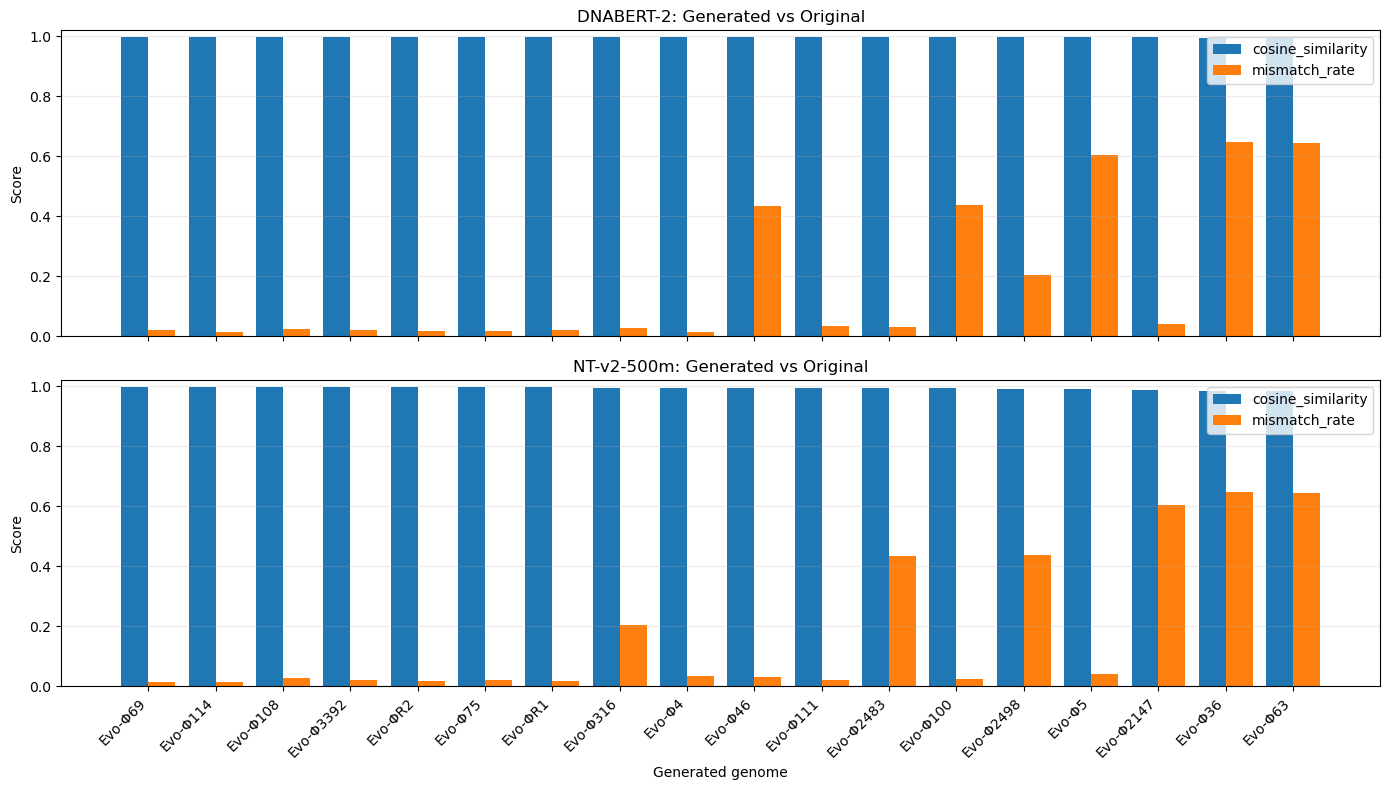

Cosine heatmap range (fixed): [0.97, 1.00]
Mismatch heatmap range: [0.013368, 0.647234]


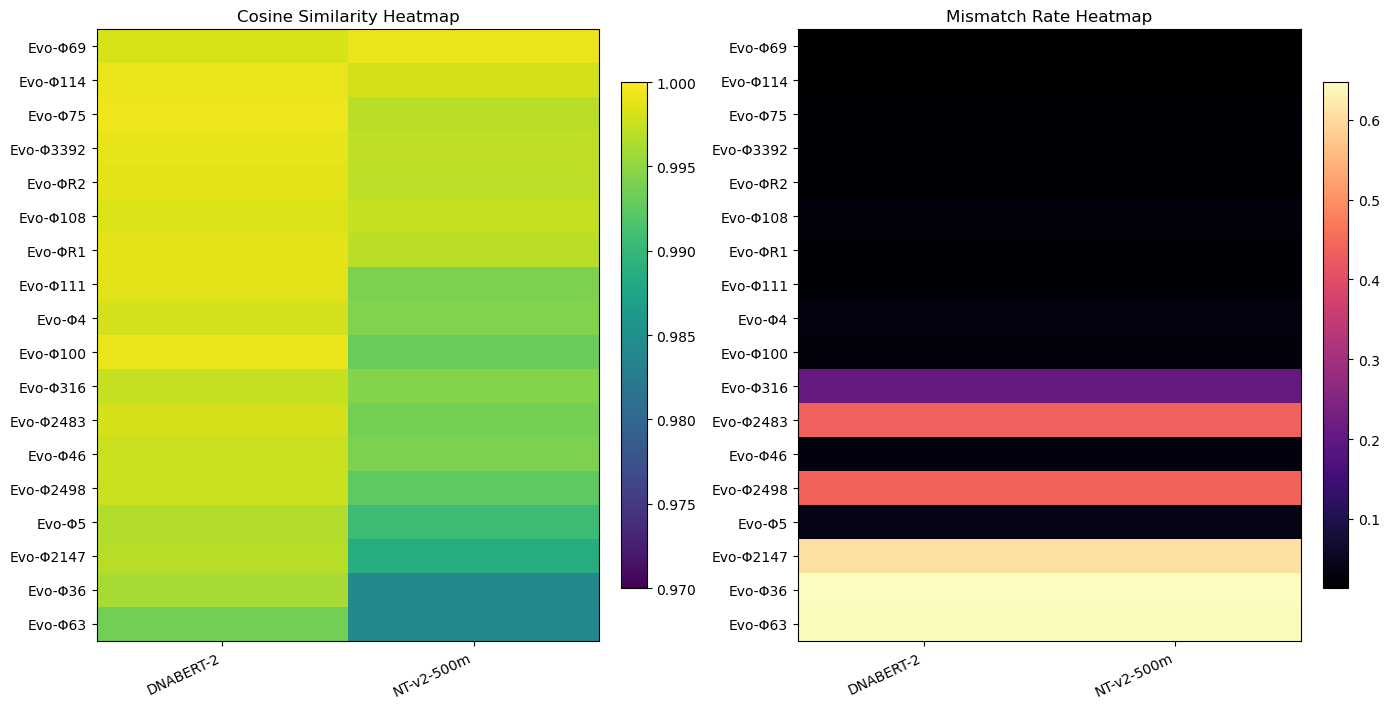

In [7]:
import matplotlib.pyplot as plt

if result_df.empty:
    print('No comparison results to visualize.')
else:
    models = list(MODEL_CONFIGS.keys())

    # 1) Model-wise bar plots
    fig, axes = plt.subplots(len(models), 1, figsize=(14, 4 * len(models)), sharex=True)
    if len(models) == 1:
        axes = [axes]

    for ax, model_label in zip(axes, models):
        sub = result_df[result_df['model'] == model_label].sort_values('cosine_similarity', ascending=False).reset_index(drop=True)
        x = np.arange(len(sub))

        ax.bar(x - 0.2, sub['cosine_similarity'].values, width=0.4, label='cosine_similarity')
        ax.bar(x + 0.2, sub['mismatch_rate'].values, width=0.4, label='mismatch_rate')
        ax.set_title(f'{model_label}: Generated vs Original')
        ax.set_ylabel('Score')
        ax.set_ylim(0, 1.02)
        ax.set_xticks(x)
        ax.set_xticklabels(sub['genome'].tolist(), rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.25)
        ax.legend(loc='best')

    axes[-1].set_xlabel('Generated genome')
    plt.tight_layout()
    plt.show()

    # 2) Cross-model heatmaps
    # rows: generated genome, cols: model
    sim_mat = result_df.pivot(index='genome', columns='model', values='cosine_similarity')
    mm_mat = result_df.pivot(index='genome', columns='model', values='mismatch_rate')

    order = sim_mat.mean(axis=1).sort_values(ascending=False).index
    sim_mat = sim_mat.loc[order, models]
    mm_mat = mm_mat.loc[order, models]

    # Fixed ranges for consistent visual comparison
    sim_vmin, sim_vmax = 0.97, 1.00

    mm_vals = mm_mat.values.astype(float)
    mm_vmin = float(np.nanpercentile(mm_vals, 2))
    mm_vmax = float(np.nanpercentile(mm_vals, 98))
    if mm_vmax <= mm_vmin:
        mm_vmin, mm_vmax = float(np.nanmin(mm_vals)), float(np.nanmax(mm_vals))

    print(f'Cosine heatmap range (fixed): [{sim_vmin:.2f}, {sim_vmax:.2f}]')
    print(f'Mismatch heatmap range: [{mm_vmin:.6f}, {mm_vmax:.6f}]')

    fig, axes = plt.subplots(1, 2, figsize=(14, max(6, 0.4 * len(sim_mat))))

    im0 = axes[0].imshow(sim_mat.values, aspect='auto', cmap='viridis', vmin=sim_vmin, vmax=sim_vmax)
    axes[0].set_title('Cosine Similarity Heatmap')
    axes[0].set_xticks(np.arange(len(sim_mat.columns)))
    axes[0].set_xticklabels(sim_mat.columns.tolist(), rotation=25, ha='right')
    axes[0].set_yticks(np.arange(len(sim_mat.index)))
    axes[0].set_yticklabels(sim_mat.index.tolist())
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(mm_mat.values, aspect='auto', cmap='magma', vmin=mm_vmin, vmax=mm_vmax)
    axes[1].set_title('Mismatch Rate Heatmap')
    axes[1].set_xticks(np.arange(len(mm_mat.columns)))
    axes[1].set_xticklabels(mm_mat.columns.tolist(), rotation=25, ha='right')
    axes[1].set_yticks(np.arange(len(mm_mat.index)))
    axes[1].set_yticklabels(mm_mat.index.tolist())
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


## Pairwise Genome Similarity Heatmap (Per Model)

각 모델 임베딩 공간에서 모든 genome(원본+생성) 간 코사인 유사도를 pairwise로 시각화합니다.


DNABERT-2 pairwise range (fixed): [0.97, 1.00]
NT-v2-500m pairwise range (fixed): [0.97, 1.00]


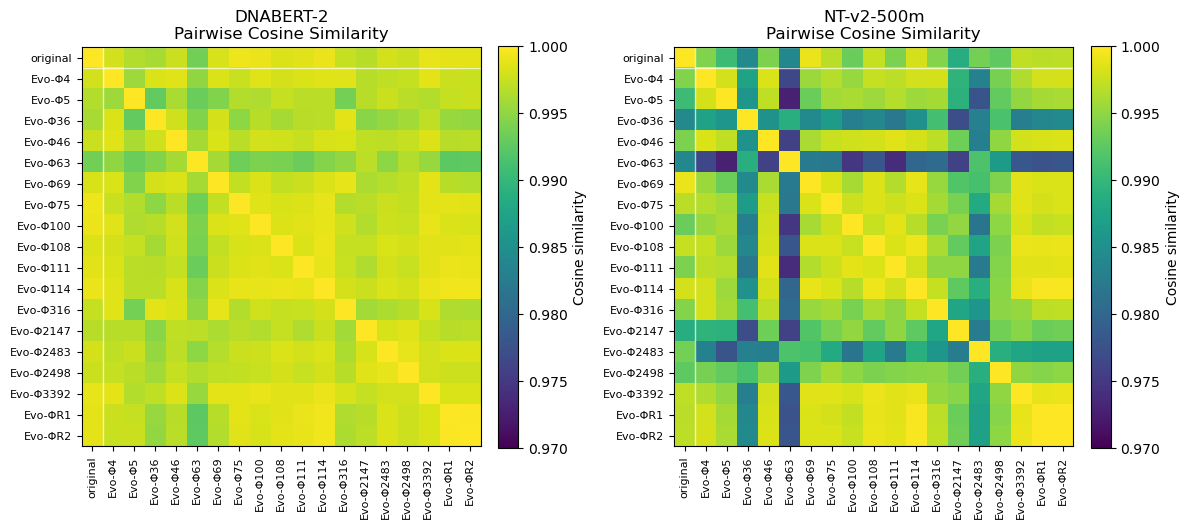

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def pairwise_cosine_matrix(x: np.ndarray) -> np.ndarray:
    # x: (n_samples, emb_dim)
    x = x.astype(np.float64, copy=False)
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1e-12, norms)
    x_norm = x / norms
    sim = x_norm @ x_norm.T
    # Numerical guard
    return np.clip(sim, -1.0, 1.0)

if not all_embeddings:
    print('Embeddings are missing. Run embedding cells first.')
else:
    genomes = df['genome'].tolist()
    models = list(MODEL_CONFIGS.keys())

    fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 8), squeeze=False)
    axes = axes[0]

    for ax, model_label in zip(axes, models):
        emb = all_embeddings[model_label]
        sim_mat = pairwise_cosine_matrix(emb)

        # Fixed range for consistent contrast across models
        vmin, vmax = 0.97, 1.00

        print(f'{model_label} pairwise range (fixed): [{vmin:.2f}, {vmax:.2f}]')

        im = ax.imshow(sim_mat, cmap='viridis', vmin=vmin, vmax=vmax, aspect='equal')
        ax.set_title(f'{model_label}\nPairwise Cosine Similarity')
        ax.set_xticks(np.arange(len(genomes)))
        ax.set_yticks(np.arange(len(genomes)))
        ax.set_xticklabels(genomes, rotation=90, fontsize=8)
        ax.set_yticklabels(genomes, fontsize=8)

        # Highlight original row/column for readability
        if 'original' in genomes:
            oi = genomes.index('original')
            ax.axhline(oi - 0.5, color='white', lw=1.0, alpha=0.7)
            ax.axhline(oi + 0.5, color='white', lw=1.0, alpha=0.7)
            ax.axvline(oi - 0.5, color='white', lw=1.0, alpha=0.7)
            ax.axvline(oi + 0.5, color='white', lw=1.0, alpha=0.7)

        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Cosine similarity')

    plt.tight_layout()
    plt.show()
